## 实验6 MSTAR图像分类-使用线性网络

**思路：**  
**1. 首先自己手写数据集MSTAR，但是加载器Dataloader直接用封装好的即可**  
**2. 然后我们手写一个三层的CNN+一层全连接层（虽然作业标题写的是使用线性网络，我们暂且认为CNN也可以吧，毕竟对于图像分类问题如果只使用全连接层则会丢失图像像素相邻的特征，当然严格来说CNN不是线性网络）**  
**3. 在训练过程中，我们使用动态增强的方法，即对每个batch中的样本进行数据增强，这可以保证网络总是在学习从未见过的样本，能很好地防止过拟合现象，大大增强网络的泛化能力**  


### 数据增强
#from torchvision.transforms  包含的数据增强进行数据扩充。


#参考下面的例子  

### 题目1：定义并训练卷积神经网络（基于Pytorch）
#利用BN层、超参数调整等方式，提升分类精度。   

In [1]:
#### 对数据集的预处理

In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset  #需要注意的是datasets在torchvision中，而Dataset在torch.utils.data中
from torchvision import transforms
from PIL import Image  #改写__getitem()__的时候会用到，用Pillow库也可以，Pillow兼容PIL
import os
from torch import optim
from torch import nn
import matplotlib.pyplot as plt

class MSTAR(Dataset):
    def __init__(self, root, mode='train', transform=None):
        self.root = root  #根目录
        self.mode = mode  #训练集or验证集文件夹的名字，本例中为tarin or validation
        self.transform = transform

        #不妨将文件名视为相应的类名
        self.classes = [
            '2S1', 'BMP2_SN_9563', 'BRDM_2', 'BTR_60', 'BTR70_SN_C71',
            'D7', 'T62', 'T72_SN_132', 'ZIL131', 'ZSU_23_4'
        ]
        self.class_to_idx = {cls:i for i,cls in enumerate(self.classes)}

        self.image_paths = []  #用来存储每个样本的路径
        self.labels = []  #用来存储每个样本对应的标签

        data_folder = os.path.join(root, mode)  #训练集or验证集文件夹的路径
        for cls in self.classes:
            cls_folder = os.path.join(data_folder, cls)  #每个类文件夹的路径
            for img_name in os.listdir(cls_folder):  #给os.listdir()中传入一个文件夹的路径，返回一个以该文件夹内全部文件的名字为元素的列表
                if img_name.lower().endswith(('jpg','png','jpeg','bmp')):  #如果照片的文件名以上述后缀为结尾的话
                    self.image_paths.append(os.path.join(cls_folder, img_name))  #装入这张照片的路径
                    self.labels.append(self.class_to_idx[cls])  #装入这张照片对应的标签（用哈希表映射获取对应整数）

    def __len__(self):  #为了自定义加载数据集，我们必须要在自己的类中重写__len__()和__getitem__()方法
        return len(self.image_paths)

    def __getitem__(self, idx):  #同上
        img = Image.open(self.image_paths[idx]).convert('L')  #convert('L')可以将图片变为单通道灰度图
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


ori_transform=transforms.Compose([  
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

batch_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.3),   #随机水平翻转
    transforms.RandomVerticalFlip(0.3),     #随机垂直翻转
    transforms.RandomRotation((-30, 30)),    #小角度随机旋转
])

#创建数据集
train_dataset = MSTAR('./mstar', mode='train', transform=ori_transform)
val_dataset = MSTAR('./mstar', mode='validation', transform=ori_transform)

temp=np.random.permutation(len(train_dataset))
train_dataset=torch.utils.data.Subset(train_dataset,temp)

#创建加载器
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)  #训练集需要打乱
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)  #验证集不必打乱

print(f"训练集大小为：{len(train_dataset)}")
print(f"验证集大小为：{len(val_dataset)}")
print(f"样本形状为：{train_dataset[0][0].shape}")

训练集大小为：2747
验证集大小为：2425
样本形状为：torch.Size([1, 128, 128])


#### 定义网络  

#### 训练\测试网络

In [2]:
class LinearClassifier(nn.Module):
    def __init__(self, input_dim=128*128, num_classes=10):
        super().__init__()
        # 第一层：Conv1 + BN1 + ReLU1
        self.conv1=nn.Conv2d(in_channels=1,out_channels=10,kernel_size=3,padding=1)
        self.bn1=nn.BatchNorm2d(10)
        self.relu1=nn.ReLU()
        self.pool1=nn.MaxPool2d(2,2)
        
        # 第二层：Conv2 + BN2 + ReLU2
        self.conv2=nn.Conv2d(in_channels=10,out_channels=20,kernel_size=3,padding=1)
        self.bn2=nn.BatchNorm2d(20)
        self.relu2=nn.ReLU()
        self.pool2=nn.MaxPool2d(2,2)

        # 第三层：Conv2 + BN2 + ReLU2
        self.conv3=nn.Conv2d(in_channels=20,out_channels=30,kernel_size=3,padding=1)
        self.bn3=nn.BatchNorm2d(30)
        self.relu3=nn.ReLU()
        self.pool3=nn.MaxPool2d(2,2)
        
        # 输出层：一层全连接层
        self.fc = nn.Linear(30*16*16, num_classes)
        # 输出层激活 Softmax（训练时会和CrossEntropy合并，这里不用写），且输出层一般不使用BN层

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x=self.pool1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x=self.pool2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x=self.pool3(x)

        x=x.view(x.shape[0],-1)
        x = self.fc(x) 
        
        return x


model = LinearClassifier()

# 损失函数：交叉熵（自带Softmax，不用手动加）
criterion = nn.CrossEntropyLoss()

weight_params=[]
bias_params=[]

"""
注意Pytorch自带的优化器会对所有的参数进行梯度下降更新
但是我只需要对权重参数weight更新，而不需要对偏置参数bias更新，所以我们需要提前把两种参数筛选出来，操作如下
"""
for name,param in model.named_parameters():
    if 'weight' in name:
        weight_params.append(param)
    else:
        bias_params.append(param)

# 优化器：Adam + L2正则化（weight_decay就是L2）
optimizer = optim.Adam(
    [
        {'params':weight_params,'weight_decay':0.01},
        {'params':bias_params,'weight_decay':0}
    ],
    lr=0.0001,  # 学习率
    betas=(0.9,0.999)
)

#学习率衰减，用来防止震荡
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max',      # 因为我们要监控 val acc
    factor=0.7,      # 变差就把学习率 ×0.7
)

def train(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    losses_train=[]
    losses_val=[]
    accuracies_train=[]
    accuracies_val=[]
    
    for epoch in range(epochs):
        
        model.train()  #此时模型在训练集上工作
        train_loss = 0.0
        correct = 0
        total = 0

        for data, target in train_loader:
            optimizer.zero_grad()
            data=batch_transform(data)
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, pred = torch.max(output, 1)
            correct += (pred == target).sum().item()
            total += target.size(0)

        train_acc = 100 * correct / total
        avg_train_loss = train_loss / len(train_loader)

        losses_train.append(avg_train_loss)
        accuracies_train.append(train_acc)


        model.eval()  #此时模型工作在验证集上
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                loss = criterion(output, target)
                val_loss += loss.item()
                _, pred = torch.max(output, 1)
                val_correct += (pred == target).sum().item()
                val_total += target.size(0)

        val_acc = 100 * val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)

        losses_val.append(avg_val_loss)
        accuracies_val.append(val_acc)

        scheduler.step(val_acc)

        print(f"Epoch: [{epoch+1}/{epochs}]  ",end="")
        print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%  |  ",end="")
        print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    plt.figure()
    plt.plot(np.arange(1,epochs+1),losses_train,label="Train Loss",color="red")
    plt.plot(np.arange(1,epochs+1),losses_val,label="Validation Loss",color="blue")
    plt.xlabel("Iteration Times")
    plt.ylabel("Corresponding Loss Value")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(np.arange(1,epochs+1),accuracies_train,label="Train Accuracy",color="red")
    plt.plot(np.arange(1,epochs+1),accuracies_val,label="Validation Accuracy",color="blue")
    plt.xlabel("Iteration Times")
    plt.ylabel("Corresponding Accuracy Value")
    plt.legend()
    plt.show()

Epoch: [1/50]  Train Loss: 2.1932 | Train Acc: 17.62%  |  Val Loss: 2.6770 | Val Acc: 11.30%
Epoch: [2/50]  Train Loss: 1.9594 | Train Acc: 29.78%  |  Val Loss: 2.7548 | Val Acc: 16.87%
Epoch: [3/50]  Train Loss: 1.7769 | Train Acc: 37.13%  |  Val Loss: 1.7603 | Val Acc: 38.06%
Epoch: [4/50]  Train Loss: 1.5725 | Train Acc: 46.60%  |  Val Loss: 1.5083 | Val Acc: 49.69%
Epoch: [5/50]  Train Loss: 1.3615 | Train Acc: 56.17%  |  Val Loss: 1.3218 | Val Acc: 58.68%
Epoch: [6/50]  Train Loss: 1.2419 | Train Acc: 62.07%  |  Val Loss: 1.1618 | Val Acc: 61.11%
Epoch: [7/50]  Train Loss: 1.1417 | Train Acc: 63.16%  |  Val Loss: 1.0751 | Val Acc: 65.53%
Epoch: [8/50]  Train Loss: 1.0041 | Train Acc: 71.31%  |  Val Loss: 0.9516 | Val Acc: 70.76%
Epoch: [9/50]  Train Loss: 0.9223 | Train Acc: 73.97%  |  Val Loss: 0.8975 | Val Acc: 72.82%
Epoch: [10/50]  Train Loss: 0.8902 | Train Acc: 74.59%  |  Val Loss: 0.8140 | Val Acc: 75.92%
Epoch: [11/50]  Train Loss: 0.8330 | Train Acc: 76.08%  |  Val Loss: 

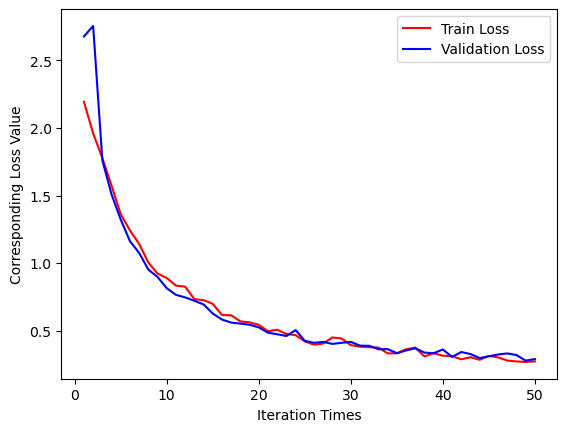

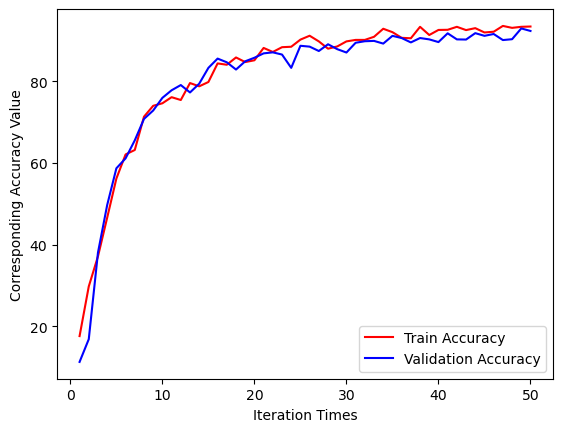

In [3]:
train(model, train_loader, val_loader, criterion, optimizer, epochs=50)

**可以看到，对于MSTAR卫星遥感数据集这种比MNIST手写体数字识别复杂的多的任务，我们的模型无论是损失还是精度，训练集和验证集的表现几乎持平，没有发生过拟合问题，最终精度约为92%，较为理想，适当调整超参数有望使最终精度达到95%甚至99%**  
**至于为何曲线频繁发生震荡？因为我们此处采用了动态数据增强的方法，其中相关的超参数是不变的，当上一时刻用来防止模型过拟合的人造噪声还算合适的时候，下一时刻这些噪声可能就会严重影响参数的更新了，为了缓解震荡问题，我们此处使用了学习率衰减的方法，当验证集精度递减时就将学习率变小一点**  

#### 实验结果与分析
#e.g.哪些策略提升了分类精度  

**1. 使用Adam作为优化器，并设置权重衰减（相当于L2正则化）**  
**2. 使用学习率衰减，尽可能削弱模型迭代到后期时因数据增强带来的人造噪声对参数更新带来的不利影响（防止震荡太过严重）**  
**3. 使用动态的数据增强，保证模型几乎不会学习到完全相同的样本，增强模型的泛化能力，有效防止过拟合现象的发生**  
**4. 使用BN层来代替dropout方法，防止过拟合现象的发生**

#### 总结

**1. 对于比较复杂的模型，或者说参数较多的模型，第一次训练时应当把学习率设置的尽量小一些，否则总是易于趋向不收敛或者严重震荡**  
**2. MBGD时batch_size不要设置的太小，因为一个batch内的数据因为样本数比起总样本数来说少，本身就带有噪声，如果设置的很小会导致严重的震荡，一般来说64或者128就可以**  
**3. 使用CNN搭建神经网络解决复杂问题时记得加入池化层，如果不加入池化层，一方面后期全连接层参数过多更新慢，另一方面此时特征图中重复信息太多，或者说噪声特征太多，模型很容易过拟合**  
**4. 善于使用数据增强来解决过拟合问题，但是具体的增强方法需要是视体情况而定，比如MSTAR卫星遥感绘制的灰度图中，因为视角是垂直俯视，所以水平随机翻转，垂直随机翻转，随机旋转对模型训练没什么影响，但如果数据集是一些动物或花草的话，最好不用使用垂直随机翻转和较大幅度的随机旋转，因为这会破坏原始样本的自然语义（就像是人脑理解不同角度的垂直俯视图时会觉得很自然，但是如果给你看一张倒过来的人的正面照你的直观感觉就是很奇怪）**  
**5. 根据要解决问题的复杂度可以适当增大epoch数**